# Kentucky School Initial Data Review

Investigate Kentucky public school education data to explore the relationship between student enrollment, chronic absenteeism, and dropout rate.

## Primary Question:
Does Chronic Absenteeism effect Dropout Rate?

School Years: 2023-2024 & 2024-2025

The enrollment data is varies at a state wide level vs a district wide. State wide will be used for over all context, but districts will then take over as I step through the data.

Libraries and Parameters

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns
import matplotlib.ticker as mticker

## KY School Data (2023-2025)

In [31]:
enrollment_2023_2024_df = pd.read_csv("../Dataset/KYRC24_OVW_Student_Enrollment.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])
enrollment_2024_2025_df = pd.read_csv("../Dataset/KYRC25_OVW_Student_Enrollment.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])

absenteeism_2023_2024_df = pd.read_csv("../Dataset/KYRC24_OVW_Chronic_Absenteeism.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])
absenteeism_2024_2025_df = pd.read_csv("../Dataset/KYRC25_OVW_Chronic_Absenteeism.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])

dropout_2023_2024_df = pd.read_csv("../Dataset/KYRC24_OVW_Dropout_Rate.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])
dropout_2024_2025_df = pd.read_csv("../Dataset/KYRC25_OVW_Dropout_Rate.csv",  dtype={'NCES ID': 'string'}, na_values=['NaN'])

regions_df = pd.read_csv("../Dataset/Ky_County_Polygons_WM.csv")

enrollment_df = pd.concat([enrollment_2023_2024_df, enrollment_2024_2025_df], ignore_index=True)
chronic_absenteeism_df = pd.concat([absenteeism_2023_2024_df, absenteeism_2024_2025_df], ignore_index=True)
dropout_rate_df = pd.concat([dropout_2023_2024_df, dropout_2024_2025_df], ignore_index=True)

## Initial Dataset Review

In [32]:
regions_df

,OBJECTID,NAME,FIPS_ID,NAME2,ADDNAME,SEAT,SEAT2,FORM_YR,PARENTCO,FIPS_NO,...,CONTACT,LAST_UPDT,XY_SOURCE,XY_ISSUES,ATT_SOURCE,ATT_ISSUES,COMMENTS,KYTC_District_Num,Shape__Area,Shape__Length
0,1,ADAIR,21001,Adair,LAKE CUMBERLAND,Columbia,COLUMBIA,1802,Green,1,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,8,1.682320e+09,176916.9036
1,2,ALLEN,21003,Allen,BARREN RIVER,Scottsville,SCOTTSVILLE,1815,"Barren, Warren",3,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,3,1.422340e+09,212158.8170
2,3,ANDERSON,21005,Anderson,BLUEGRASS,Lawrenceburg,LAWRENCEBURG,1827,"Franklin, Mercer, Washington",5,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,7,8.534822e+08,187271.1613
3,4,BALLARD,21007,Ballard,PURCHASE,Wickliffe,WICKLIFFE,1842,"Hickman, McCracken",7,...,KIM ANNESS,7/23/2015 0:00,"OHIO V. KENTUCKY, 444 U.S. 335 (1980)",NaN,SECRETARY OF STATE,NaN,BOUNDARY UPDATED TO MATCH SUPREME COURT CASE R...,1,1.116332e+09,169743.5539
4,5,BARREN,21009,Barren,BARREN RIVER,Glasgow,GLASGOW,1799,"Green, Warren",9,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,3,2.032351e+09,235199.6736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,116,WAYNE,21231,Wayne,LAKE CUMBERLAND,Monticello,MONTICELLO,1801,"Cumberland, Pulaski",231,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,8,1.959573e+09,214715.8624
116,117,WEBSTER,21233,Webster,GREEN RIVER,Dixon,DIXON,1860,"Henderson, Hopkins, Union",233,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,2,1.384222e+09,197143.2294
117,118,WHITLEY,21235,Whitley,CUMBERLAND VALLEY,Williamsburg,WILLIAMSBURG,1818,Knox,235,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,11,1.799520e+09,238465.4839
118,119,WOLFE,21237,Wolfe,KENTUCKY RIVER,Campton,CAMPTON,1860,"Breathitt, Morgan, Owsley, Powell",237,...,"TRANSPORTATION SYSTEMS BRANCH MANAGER, DIVISIO...",7/1/1993 0:00,BOUNDARY DIGITIZED FROM USGS 7.5 MINUTE TOPOGR...,NaN,SECRETARY OF STATE,NaN,NaN,10,9.241010e+08,184878.7025


In [33]:
enrollment_df

,School Year,County Number,County Name,District Number,District Name,School Number,School Name,School Code,State School Id,NCES ID,...,Grade 4,Grade 5,Grade 6,Grade 7,Grade 8,Grade 9,Grade 10,Grade 11,Grade 12,Grade 14
0,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"49,321","49,728","46,144","49,278","50,090","56,075","54,149","50,192","47,786",653.0
1,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"23,912","24,119","22,146","23,926","24,063","27,061","26,353","24,607","23,210",217.0
2,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"25,409","25,609","23,998","25,352","26,027","29,014","27,796","25,585","24,576",436.0
3,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"5,279","5,381","4,763","5,474","5,541","6,605","6,294","5,566","5,059",103.0
4,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,84,68,59,59,72,79,66,78,68,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46223,20242025,106.0,SHELBY,531,Shelby County,25.0,Cultivate Virtual Learning Academy,531025,106531025.0,210532000000,...,NaN,NaN,0,0,0,1,3,6,11,NaN
46224,20242025,106.0,SHELBY,531,Shelby County,25.0,Cultivate Virtual Learning Academy,531025,106531025.0,210532000000,...,NaN,NaN,0,0,0,1,0,2,0,NaN
46225,20242025,106.0,SHELBY,531,Shelby County,25.0,Cultivate Virtual Learning Academy,531025,106531025.0,210532000000,...,NaN,NaN,1,1,0,0,3,2,4,NaN
46226,20242025,106.0,SHELBY,531,Shelby County,25.0,Cultivate Virtual Learning Academy,531025,106531025.0,210532000000,...,NaN,NaN,0,0,0,0,1,1,0,NaN


In [34]:
chronic_absenteeism_df

,School Year,County Number,County Name,District Number,District Name,School Number,School Name,School Code,State School Id,NCES ID,CO-OP,CO-OP Code,School Type,Grade,Demographic,Suppressed,Chronically Absent Students,Students Enrolled 10 or More Days,Chronic Absenteeism Rate
0,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Grades,All Students,No,"186,415","664,910",28
1,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Grades,Female,No,"91,571","321,064",28.5
2,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Grades,Male,No,"94,844","343,846",27.6
3,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Grades,African American,No,"25,283","73,438",34.4
4,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Grades,American Indian or Alaska Native,No,290,962,30.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543271,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,14th,Foster Care,Yes,*,*,*
543272,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,14th,Gifted and Talented,Yes,*,*,*
543273,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,14th,Homeless,Yes,*,*,*
543274,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,14th,Migrant,Yes,*,*,*


In [35]:
dropout_rate_df

,School Year,County Number,County Name,District Number,District Name,School Number,School Name,School Code,State School Id,NCES ID,CO-OP,CO-OP Code,School Type,Demographic,Suppressed,Dropout Rate
0,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Students,N,1.3
1,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,Female,N,1.1
2,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,Male,N,1.5
3,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,African American,N,2.2
4,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,American Indian or Alaska Native,N,2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24529,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,Student without Disabilities (IEP),N,0
24530,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,English Learner,Y,*
24531,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,Non English Learner,N,0
24532,20242025,73.0,MADISON,606,Model Laboratory Schools at EKU,460.0,Model High School,606460,73606460.0,2.10029E+11,NaN,NaN,B1,Homeless,NaN,


## Data Cleanup

In [36]:
#### Functions
def asterisk_conversion(df, column_name):
    asterisk_convert_df = df.copy()
    asterisk_convert_df[column_name] = asterisk_convert_df[column_name].replace('*', pd.NA)
    asterisk_convert_df[column_name] = pd.to_numeric(asterisk_convert_df[column_name],  errors='coerce')
    return asterisk_convert_df

In [37]:
regions_df = regions_df[['NAME', 'REGION']]
regions_df = regions_df.rename(columns={'NAME': 'county_name', 'REGION': 'region'}).drop_duplicates()

regions_df

,county_name,region
0,ADAIR,SOUTH CENTRAL REGION
1,ALLEN,SOUTH CENTRAL REGION
2,ANDERSON,BLUEGRASS REGION
3,BALLARD,WESTERN REGION
4,BARREN,SOUTH CENTRAL REGION
...,...,...
115,WAYNE,SOUTH CENTRAL REGION
116,WEBSTER,WESTERN REGION
117,WHITLEY,EAST REGION
118,WOLFE,EAST REGION


In [38]:
enrollment_df = enrollment_df.rename(columns={
    'School Year': 'school_year',
    'County Number': 'county_number',
    'County Name': 'county_name',
    'District Number': 'district_number',
    'District Name': 'district_name',
    'School Number': 'school_number',
    'School Name': 'school_name',
    'School Code': 'school_code',
    'State School Id': 'state_school_id',
    'NCES ID': 'nces_id',
    'CO-OP': 'co_op',
    'CO-OP Code': 'co_op_code',
    'School Type': 'school_type',
    'Demographic': 'demographic',
    'All Grades': 'all_grades',
    'Preschool': 'grade_preschool',
    'K': 'grade_k',
    'Grade 1': 'grade_1',
    'Grade 2': 'grade_2',
    'Grade 3': 'grade_3',
    'Grade 4': 'grade_4',
    'Grade 5': 'grade_5',
    'Grade 6': 'grade_6',
    'Grade 7': 'grade_7',
    'Grade 8': 'grade_8',
    'Grade 9': 'grade_9',
    'Grade 10': 'grade_10',
    'Grade 11': 'grade_11',
    'Grade 12': 'grade_12',
    'Grade 14': 'grade_14'
}).drop_duplicates()



enrollment_df.head()

,school_year,county_number,county_name,district_number,district_name,school_number,school_name,school_code,state_school_id,nces_id,...,grade_4,grade_5,grade_6,grade_7,grade_8,grade_9,grade_10,grade_11,grade_12,grade_14
0,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"49,321","49,728","46,144","49,278","50,090","56,075","54,149","50,192","47,786",653.0
1,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"23,912","24,119","22,146","23,926","24,063","27,061","26,353","24,607","23,210",217.0
2,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"25,409","25,609","23,998","25,352","26,027","29,014","27,796","25,585","24,576",436.0
3,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,"5,279","5,381","4,763","5,474","5,541","6,605","6,294","5,566","5,059",103.0
4,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,...,84,68,59,59,72,79,66,78,68,0.0


In [39]:
chronic_absenteeism_df = chronic_absenteeism_df.rename(columns={
    'School Year': 'school_year',
    'County Number': 'county_number',
    'County Name': 'county_name',
    'District Number': 'district_number',
    'District Name': 'district_name',
    'School Number': 'school_number',
    'School Name': 'school_name',
    'School Code': 'school_code',
    'State School Id': 'state_school_id',
    'NCES ID': 'nces_id',
    'CO-OP': 'co_op',
    'CO-OP Code': 'co_op_code',
    'School Type': 'school_type',
    'Grade': 'grade_level',
    'Demographic': 'demographic',
    'Suppressed': 'suppressed',
    'Chronically Absent Students': 'chronically_absent_students',
    'Students Enrolled 10 or More Days': 'enrolled_10_plus_days',
    'Chronic Absenteeism Rate': 'chronic_absenteeism_rate'
}).drop_duplicates()



# asterisk_conversion
chronic_absenteeism_df = asterisk_conversion(chronic_absenteeism_df, 'chronically_absent_students')
chronic_absenteeism_df = asterisk_conversion(chronic_absenteeism_df, 'enrolled_10_plus_days')
chronic_absenteeism_df = asterisk_conversion(chronic_absenteeism_df, 'chronic_absenteeism_rate')


In [40]:
dropout_rate_df = dropout_rate_df.rename(columns={
    'School Year': 'school_year',
    'County Number': 'county_number',
    'County Name': 'county_name',
    'District Number': 'district_number',
    'District Name': 'district_name',
    'School Number': 'school_number',
    'School Name': 'school_name',
    'School Code': 'school_code',
    'State School Id': 'state_school_id',
    'NCES ID': 'nces_id',
    'CO-OP': 'co_op',
    'CO-OP Code': 'co_op_code',
    'School Type': 'school_type',
    'Demographic': 'demographic',
    'Suppressed': 'suppressed',
    'Dropout Rate': 'dropout_rate',
}).drop_duplicates()


dropout_rate_df = asterisk_conversion(dropout_rate_df, 'dropout_rate')

dropout_rate_df.head(100)

,school_year,county_number,county_name,district_number,district_name,school_number,school_name,school_code,state_school_id,nces_id,co_op,co_op_code,school_type,demographic,suppressed,dropout_rate
0,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,All Students,N,1.3
1,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,Female,N,1.1
2,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,Male,N,1.5
3,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,African American,N,2.2
4,20232024,NaN,NaN,999,All Districts,NaN,All Schools,999000,NaN,<NA>,NaN,NaN,NaN,American Indian or Alaska Native,N,2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20232024,2.0,ALLEN,5,Allen County,15.0,James E Bazzell Middle School,5015,2005015.0,2.10007E+11,GRREC,902.0,A1,Asian,Y,NaN
96,20232024,2.0,ALLEN,5,Allen County,15.0,James E Bazzell Middle School,5015,2005015.0,2.10007E+11,GRREC,902.0,A1,Hispanic or Latino,N,0.0
97,20232024,2.0,ALLEN,5,Allen County,15.0,James E Bazzell Middle School,5015,2005015.0,2.10007E+11,GRREC,902.0,A1,Native Hawaiian or Pacific Islander,NaN,NaN
98,20232024,2.0,ALLEN,5,Allen County,15.0,James E Bazzell Middle School,5015,2005015.0,2.10007E+11,GRREC,902.0,A1,Two or More Races,N,0.0


## SQL DB Creation

In [41]:
conn = sqlite3.connect('../Dataset/dbo/ky_school_systems.db')

ky_regions_df = (regions_df[['county_name', 'region']]).drop_duplicates()

ky_district_df = (enrollment_df[['district_number','district_name','county_number','county_name']]).drop_duplicates()

ky_school_df = (enrollment_df[['school_code','school_number','school_name','state_school_id','nces_id','co_op','co_op_code','school_type','district_number']]).drop_duplicates()

ky_school_year_df = (enrollment_df[['school_year', 'school_code', 'district_number', 'county_name']]).drop_duplicates()

ky_school_enrollment_df = pd.melt(
    enrollment_df,
    id_vars = ['school_year','school_code','demographic'], 
    value_vars = ['all_grades','grade_preschool', 'grade_k', 
                  'grade_1', 'grade_2', 'grade_3', 'grade_4', 'grade_5', 
                  'grade_6', 'grade_7', 'grade_8', 
                  'grade_9', 'grade_10', 'grade_11', 'grade_12', 
                  'grade_14'],
    var_name = 'grade_level',
    value_name = 'enrollment_total').drop_duplicates()

ky_school_chron_abs_df = (chronic_absenteeism_df[['school_year', 'school_code', 'demographic', 'grade_level', 'suppressed', 'chronically_absent_students', 'enrolled_10_plus_days', 'chronic_absenteeism_rate']]).drop_duplicates()

ky_school_dropout_rate_df = (dropout_rate_df[['school_year', 'school_code', 'demographic', 'suppressed', 'dropout_rate']]).drop_duplicates()

ky_regions_df.to_sql('ky_regions', conn, index=False, if_exists='replace')
ky_district_df.to_sql('ky_district', conn, index=False, if_exists='replace')
ky_school_df.to_sql('ky_school', conn, index=False, if_exists='replace')
ky_school_year_df.to_sql('ky_school_year', conn, index=False, if_exists='replace')
ky_school_enrollment_df.to_sql('ky_school_enrollment', conn, index=False, if_exists='replace')
ky_school_chron_abs_df.to_sql('ky_school_chronic_absenteeism', conn, index=False, if_exists='replace')
ky_school_dropout_rate_df.to_sql('ky_school_dropout_rate', conn, index=False, if_exists='replace')

conn.commit()


In [42]:
abs_df = chronic_absenteeism_df[
    (chronic_absenteeism_df['grade_level'] == 'All Grades') &
    (chronic_absenteeism_df['demographic'] == 'All Students') &
    (chronic_absenteeism_df['school_name'] != 'All Schools')
].copy()


In [43]:
dropout_df = dropout_rate_df[
    (dropout_rate_df['demographic'] == 'All Students') &
    (dropout_rate_df['school_name'] != 'All Schools')
]

In [44]:
abs_do_merge_check = abs_df.merge(
    dropout_df[['school_year', 'school_code', 'dropout_rate']], 
    on=['school_year', 'school_code'], 
    how='outer',
    indicator=True,
    validate='one_to_one')


In [45]:
m_f_enroll_df = ky_school_enrollment_df[
    (ky_school_enrollment_df['school_code'] == 999000) &
    (ky_school_enrollment_df['demographic'].isin(['Male','Female']))]

m_f_enroll_df


,school_year,school_code,demographic,grade_level,enrollment_total
1,20232024,999000,Female,all_grades,"331,429"
2,20232024,999000,Male,all_grades,"354,795"
23093,20242025,999000,Female,all_grades,"329,446"
23094,20242025,999000,Male,all_grades,"352,567"
46229,20232024,999000,Female,grade_preschool,"13,950"
...,...,...,...,...,...
670286,20242025,999000,Male,grade_12,"25,207"
693421,20232024,999000,Female,grade_14,217.0
693422,20232024,999000,Male,grade_14,436.0
716513,20242025,999000,Female,grade_14,217.0


In [46]:
enrollment_df[
    enrollment_df["district_number"] == 880
][
    [
    "school_year",
    "district_number",
    "district_name",
    "county_number",
    "county_name",
    "school_code",
    "school_name"
    ]
].drop_duplicates()

,school_year,district_number,district_name,county_number,county_name,school_code,school_name
23058,20232024,880,Kentucky National Guard Youth ChalleNGe Academies,37.0,FRANKLIN,880000,All Schools
23070,20232024,880,Kentucky National Guard Youth ChalleNGe Academies,37.0,FRANKLIN,880100,Appalachian Challenge Academy
23080,20232024,880,Kentucky National Guard Youth ChalleNGe Academies,37.0,FRANKLIN,880101,Bluegrass Challenge Academy
45949,20242025,880,Kentucky National Guard Youth ChalleNGe Academies,52.0,HENRY,880000,All Schools
45963,20242025,880,Kentucky National Guard Youth ChalleNGe Academies,52.0,HENRY,880100,Appalachian Challenge Academy
45974,20242025,880,Kentucky National Guard Youth ChalleNGe Academies,52.0,HENRY,880101,Bluegrass Challenge Academy


In [47]:
test1 = """SELECT
    school_code,
    COUNT(*) AS row_count,
    COUNT(DISTINCT school_name) AS name_count,
    COUNT(DISTINCT district_number) AS district_count,
    COUNT(DISTINCT nces_id) AS nces_count,
    COUNT(DISTINCT school_type) AS type_count
FROM ky_school
GROUP BY school_code
HAVING COUNT(*) > 1
ORDER BY row_count DESC;
"""
test1t = pd.read_sql(test1, conn)
test1t

,school_code,row_count,name_count,district_count,nces_count,type_count
0,880101,2,1,1,2,1
1,880100,2,1,1,2,1
2,606460,2,1,1,2,1
3,606450,2,1,1,2,1
4,606000,2,1,1,1,0
...,...,...,...,...,...,...
1508,1016,2,1,1,2,1
1509,1014,2,1,1,2,1
1510,1012,2,1,1,2,1
1511,1010,2,1,1,2,1


In [48]:
# Naming template 
# ky_regions r
# ky_district d
# ky_school s
# ky_school_year_df sy
# ky_school_enrollment se
# ky_school_chronic_absenteeism sa
# ky_school_dropout_rate sd

# joins template:
# LEFT JOIN ky_district d ON r.ky_regions = d.district_number
# LEFT JOIN ky_district d ON s.district_number = d.district_number
# LEFT JOIN ky_school_enrollment se ON s.school_code = se.school_code
# LEFT JOIN ky_school_chronic_absenteeism sa ON s.school_code = sa.school_code
# LEFT JOIN ky_school_dropout_rate sa ON s.school_code = sd.school_code

In [49]:
# Number of Schools in KY School Database
# Confirmed and validated in Excel

# This checks to see what schools are not in 20242025
# SELECT distinct(s.school_name)
# FROM ky_school s
# LEFT JOIN ky_school_enrollment se ON s.school_code = se.school_code
# WHERE se.school_year <> '20242025'
# GROUP BY se.school_year
# ORDER BY count (DISTINCT school_name) desc

# SELECT  distinct(se.school_year), count (DISTINCT state_school_id) as "Schools in KY Database"
# FROM ky_school_year sy
# LEFT JOIN ky_school s on s.school_code = sy.school_code
# LEFT JOIN ky_school_enrollment se ON s.school_code = se.school_code
# WHERE school_name <> 'All Schools'
# GROUP BY se.school_year
# ORDER BY count (DISTINCT school_name) desc

ky_school_total = """ 

SELECT  distinct(se.school_year), count (DISTINCT state_school_id) as "Schools in KY Database"
FROM ky_school_year sy
LEFT JOIN ky_school s ON s.school_code = sy.school_code 
LEFT JOIN ky_school_enrollment se ON s.school_code = se.school_code 
WHERE school_name <> 'All Schools'
GROUP BY se.school_year
ORDER BY count (DISTINCT school_name) desc
"""
school_total_result = pd.read_sql(ky_school_total, conn)
school_total_result

,school_year,Schools in KY Database
0,20242025,1398
1,20232024,1398


20232024 - 1398 schools
20242025 - 1398 schools

In [50]:
ky_region_school_total = """
SELECT sy.school_year, r.region, COUNT(DISTINCT s.state_school_id) AS school_count
FROM ky_school_year sy
JOIN ky_regions r ON r.county_name = sy.county_name
JOIN ky_school s ON s.school_code = sy.school_code
WHERE s.school_name <> 'All Schools'
GROUP BY sy.school_year, r.region
ORDER BY sy.school_year, school_count DESC;

"""
ky_region_school_result = pd.read_sql(ky_region_school_total, conn)
ky_region_school_result

,school_year,region,school_count
0,20232024,SOUTH CENTRAL REGION,265
1,20232024,GREATER LOUISVILLE REGION,240
2,20232024,BLUEGRASS REGION,233
3,20232024,WESTERN REGION,216
4,20232024,EAST REGION,209
5,20232024,NORTHERN KENTUCKY REGION,122
6,20232024,NORTHEAST REGION,113
7,20242025,SOUTH CENTRAL REGION,266
8,20242025,GREATER LOUISVILLE REGION,248
9,20242025,BLUEGRASS REGION,227


In [51]:
ky_school_enroll_total = """ 

SELECT  se.school_year, se.grade_level, se.enrollment_total
FROM ky_school_year sy
LEFT JOIN ky_school s on s.school_code = sy.school_code
LEFT JOIN ky_school_enrollment se ON s.school_code = se.school_code
WHERE school_name = 'All Schools'
AND se.demographic = 'All Students'
AND se.school_code = '999000'
GROUP BY se.school_year
ORDER BY count (DISTINCT school_name) desc
"""
school_enroll_total_result = pd.read_sql(ky_school_enroll_total, conn)
school_enroll_total_result


,school_year,grade_level,enrollment_total
0,20242025,all_grades,"682,013"
1,20232024,all_grades,"686,224"


In [52]:
ky_school_enroll_mf_total = """ 

SELECT  
    se.school_year,
    se.grade_level,
    se.demographic,
    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER)
        AS enrollment_total

FROM  ky_school_enrollment se
LEFT JOIN ky_school_chronic_absenteeism ca 
    ON ca.school_year = se.school_year 
    AND ca.school_code = se.school_code
    AND ca.demographic = se.demographic
    AND ca.grade_level = 'All Grades'

LEFT JOIN ky_school_dropout_rate dr 
    ON dr.school_year = se.school_year 
    AND dr.school_code = ca.school_code
    AND dr.demographic = se.demographic

WHERE se.school_code = '999000'
AND se.demographic in ('Male', 'Female')
AND se.grade_level = 'all_grades'
ORDER BY se.school_year, se.demographic, se.grade_level
"""
school_enroll_mf_total_result = pd.read_sql(ky_school_enroll_mf_total, conn)
school_enroll_mf_total_result

,school_year,grade_level,demographic,enrollment_total
0,20232024,all_grades,Female,331429
1,20232024,all_grades,Male,354795
2,20242025,all_grades,Female,329446
3,20242025,all_grades,Male,352567


In [53]:
ky_school_enroll_mf_rates_total = """ 

SELECT  
    se.school_year,
    se.grade_level,
    se.demographic,

    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER)
        AS enrollment_total,

    ca.chronic_absenteeism_rate,

    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER)
        * (ca.chronic_absenteeism_rate / 100.0)
        AS estimated_absenteeism_qty,

    dr.dropout_rate,

    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER)
        * (dr.dropout_rate / 100.0)
        AS estimated_dropout_qty
FROM  ky_school_enrollment se
LEFT JOIN ky_school_chronic_absenteeism ca 
    ON ca.school_year = se.school_year 
    AND ca.school_code = se.school_code
    AND ca.demographic = se.demographic
    AND ca.grade_level = 'All Grades'

LEFT JOIN ky_school_dropout_rate dr 
    ON dr.school_year = se.school_year 
    AND dr.school_code = ca.school_code
    AND dr.demographic = se.demographic

WHERE se.school_code = '999000'
AND se.demographic in ('Male', 'Female')
AND se.grade_level = 'all_grades'
ORDER BY se.school_year, se.demographic, se.grade_level
"""
school_enroll_mf_rates_total_result = pd.read_sql(ky_school_enroll_mf_rates_total, conn)
school_enroll_mf_rates_total_result

,school_year,grade_level,demographic,enrollment_total,chronic_absenteeism_rate,estimated_absenteeism_qty,dropout_rate,estimated_dropout_qty
0,20232024,all_grades,Female,331429,28.5,94457.265,1.1,3645.719
1,20232024,all_grades,Male,354795,27.6,97923.420,1.5,5321.925
2,20242025,all_grades,Female,329446,25.4,83679.284,0.9,2965.014
3,20242025,all_grades,Male,352567,24.7,87084.049,1.3,4583.371


In [54]:
ky_school_enroll_all_total = """ 

SELECT DISTINCT
    se.school_year,
    s.school_name,
    se.grade_level,
    se.demographic,
    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER) AS enrollment_total,
    ca.chronic_absenteeism_rate,
    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER) * (ca.chronic_absenteeism_rate / 100.0) AS estimated_absenteeism_qty,
    dr.dropout_rate,
    CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER) * (dr.dropout_rate / 100.0) AS estimated_dropout_qty
FROM  ky_school_enrollment se

LEFT JOIN ky_school s
    ON s.school_code = se.school_code

LEFT JOIN ky_school_chronic_absenteeism ca 
    ON ca.school_year = se.school_year 
    AND ca.school_code = se.school_code
    AND ca.demographic = se.demographic
    AND ca.grade_level = 'All Grades'

LEFT JOIN ky_school_dropout_rate dr 
    ON dr.school_year = se.school_year 
    AND dr.school_code = ca.school_code
    AND dr.demographic = se.demographic

WHERE s.school_name != 'All Schools'
AND se.demographic in ('All Students')
ORDER BY se.school_year, se.demographic, se.grade_level
"""
school_enroll_mf_all_result = pd.read_sql(ky_school_enroll_all_total, conn)
school_enroll_mf_all_result


,school_year,school_name,grade_level,demographic,enrollment_total,chronic_absenteeism_rate,estimated_absenteeism_qty,dropout_rate,estimated_dropout_qty
0,20232024,Adair County High School,all_grades,All Students,847.0,39.2,332.024,0.6,5.082
1,20232024,Adair Learning Academy,all_grades,All Students,263.0,NaN,NaN,NaN,NaN
2,20232024,Adair County Middle School,all_grades,All Students,632.0,32.3,204.136,0.0,0.000
3,20232024,Adair County Elementary School,all_grades,All Students,605.0,22.5,136.125,NaN,NaN
4,20232024,Adair County Primary Center,all_grades,All Students,722.0,27.4,197.828,NaN,NaN
...,...,...,...,...,...,...,...,...,...
45001,20242025,Clear Creek Elementary,grade_preschool,All Students,NaN,13.0,NaN,NaN,NaN
45002,20242025,Wright Elementary,grade_preschool,All Students,NaN,13.2,NaN,NaN,NaN
45003,20242025,Northside Early Childhood Center,grade_preschool,All Students,279.0,NaN,NaN,NaN,NaN
45004,20242025,Ascension Academy,grade_preschool,All Students,NaN,65.3,NaN,NaN,NaN


In [55]:
county_rates = """ 

SELECT
    se.school_year,
    sy.county_name,
    SUM(CAST(REPLACE(se.enrollment_total, ',', '') AS INTEGER)) AS enrollment_total,
    AVG(ca.chronic_absenteeism_rate) AS avg_chronic_absent,
    AVG(dr.dropout_rate) AS avg_dropout_rate

FROM ky_school_enrollment se

LEFT JOIN ky_school_year sy
    ON sy.school_year = se.school_year
    AND sy.school_code = se.school_code

LEFT JOIN ky_school_chronic_absenteeism ca 
    ON ca.school_year = se.school_year 
    AND ca.school_code = se.school_code
    AND ca.demographic = se.demographic
    AND ca.grade_level = 'All Grades'

LEFT JOIN ky_school_dropout_rate dr 
    ON dr.school_year = se.school_year 
    AND dr.school_code = se.school_code
    AND dr.demographic = se.demographic

WHERE se.demographic = 'All Students'
  AND se.grade_level = 'all_grades'
  AND se.school_code % 1000 <> 0
  AND se.school_year = '20242025'

GROUP BY
    se.school_year,
    sy.county_name

ORDER BY
    AVG(dr.dropout_rate) DESC,
    se.school_year,
    sy.county_name

LIMIT 10

"""
county_rates_result = pd.read_sql(county_rates, conn)

top10_dropout_rate_df = county_rates_result
top10_dropout_rate_df

,school_year,county_name,enrollment_total,avg_chronic_absent,avg_dropout_rate
0,20242025,KNOTT,2279,49.342857,2.085714
1,20242025,JEFFERSON,110061,33.327742,1.327907
2,20242025,OWEN,1764,26.833333,1.150000
3,20242025,FAYETTE,46677,28.146154,1.077778
4,20242025,CAMPBELL,12131,16.495238,1.050000
5,20242025,WASHINGTON,1994,16.625000,1.000000
6,20242025,HENRY,3551,19.242857,0.966667
7,20242025,MAGOFFIN,2030,49.320000,0.950000
8,20242025,CHRISTIAN,10290,26.492857,0.900000
9,20242025,ALLEN,3411,23.820000,0.750000


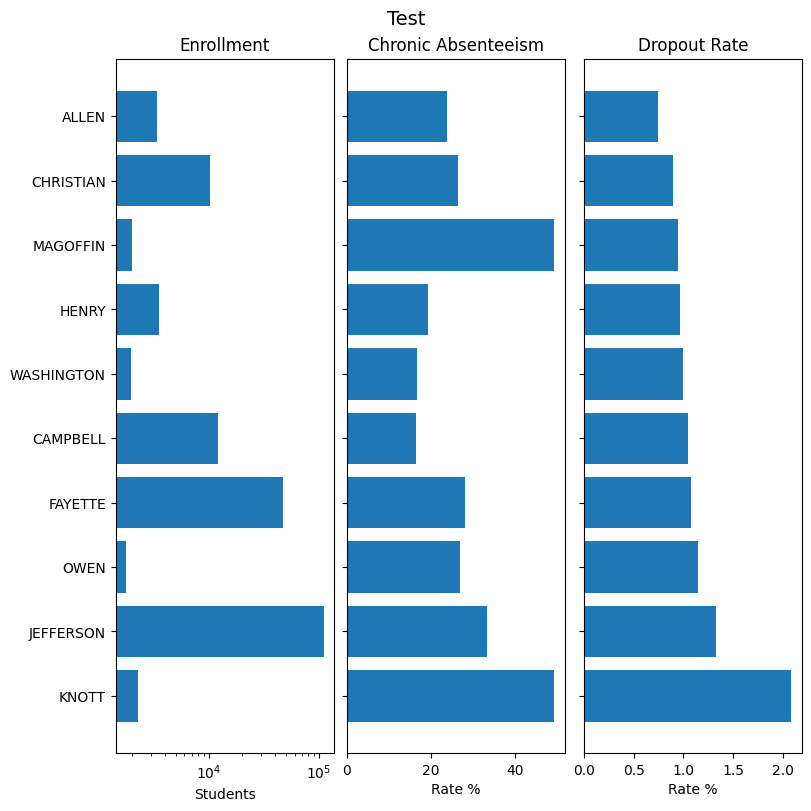

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(8, 8), sharey=True, layout='constrained')

ax[0].barh(
    top10_dropout_rate_df['county_name'],
    top10_dropout_rate_df['enrollment_total'])

ax[0].set_xscale('log')

ax[0].set_title('Enrollment')
ax[0].set_xlabel('Students')

ax[1].barh(    
    top10_dropout_rate_df['county_name'],
    top10_dropout_rate_df['avg_chronic_absent'])

ax[1].set_title('Chronic Absenteeism')
ax[1].set_xlabel('Rate %')

ax[2].barh(    
    top10_dropout_rate_df['county_name'],
    top10_dropout_rate_df['avg_dropout_rate'])

ax[2].set_title('Dropout Rate')
ax[2].set_xlabel('Rate %')

fig.suptitle('Test', fontsize=14)

plt.show()

In [57]:
regional_rates = """ 

SELECT
    se.school_year,
    r.region,
    avg(chronic_absenteeism_rate) AS avg_chronic_absent,
    avg(dropout_rate) AS avg_dropout_rate

FROM  ky_school_enrollment se

LEFT JOIN ky_school s
    ON s.school_code = se.school_code

LEFT JOIN ky_school_chronic_absenteeism ca 
    ON ca.school_year = se.school_year 
    AND ca.school_code = se.school_code
    AND ca.demographic = se.demographic
    AND ca.grade_level = 'All Grades'

LEFT JOIN ky_school_dropout_rate dr 
    ON dr.school_year = se.school_year 
    AND dr.school_code = ca.school_code
    AND dr.demographic = se.demographic

LEFT JOIN ky_district d
    ON d.district_number = s.district_number 

LEFT JOIN ky_regions r
    ON r.county_name = d.county_name 

WHERE se.demographic in ('All Students')
AND se.grade_level = 'all_grades'
AND se.school_code % 1000 <> 0


group by     
    se.school_year,
    r.region
ORDER BY     
    se.school_year,
    r.region

"""
regional_rates_result = pd.read_sql(regional_rates, conn)
regional_rates_result

,school_year,region,avg_chronic_absent,avg_dropout_rate
0,20232024,BLUEGRASS REGION,28.969157,0.462963
1,20232024,EAST REGION,43.246277,0.383415
2,20232024,GREATER LOUISVILLE REGION,33.429821,0.885714
3,20232024,NORTHEAST REGION,32.615578,0.348780
4,20232024,NORTHERN KENTUCKY REGION,18.841743,0.402222
5,20232024,SOUTH CENTRAL REGION,26.851129,0.336453
6,20232024,WESTERN REGION,23.769845,0.477465
7,20242025,BLUEGRASS REGION,25.689951,0.498519
8,20242025,EAST REGION,38.657029,0.318537
9,20242025,GREATER LOUISVILLE REGION,28.884009,0.981429


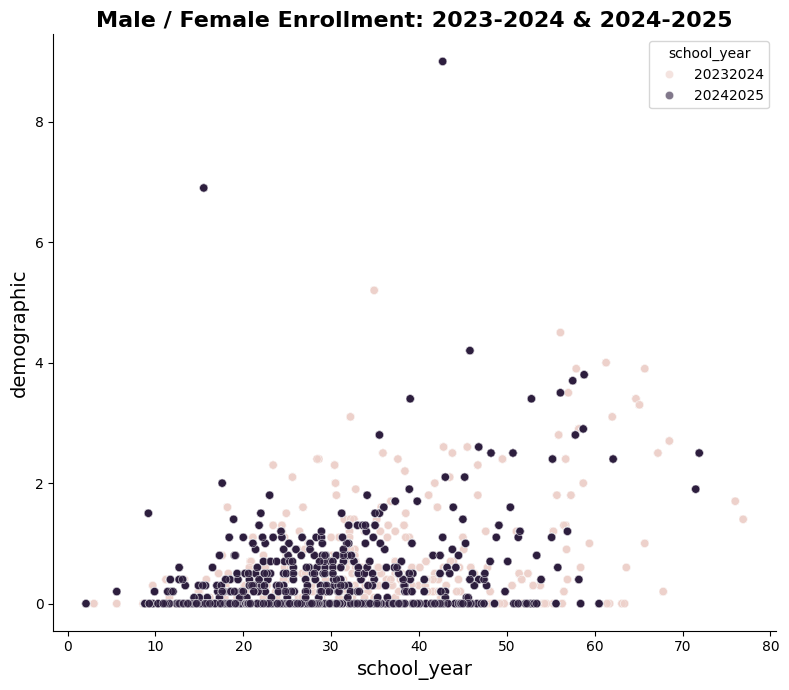

In [ ]:
plt.figure(figsize=(8,7))

sns.scatterplot(data=school_enroll_mf_all_result,
            x='chronic_absenteeism_rate',
            y='dropout_rate',
            hue='school_year',
            alpha= 0.6)

plt.xlabel("school_year", fontsize=14)
plt.ylabel("demographic", fontsize=14)
plt.title("chronic absenteeism vs dropout rate", fontsize=16, fontweight="bold", color="#000000")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Visuals

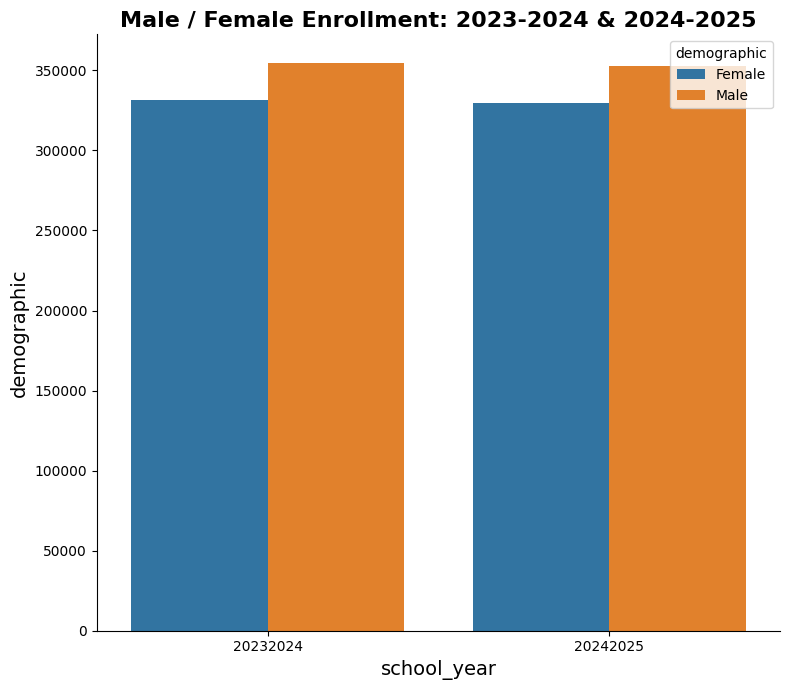

In [59]:
plt.figure(figsize=(8,7))

sns.barplot(school_enroll_mf_total_result,
            x='school_year',
            y='enrollment_total',
            hue='demographic')

plt.xlabel("school_year", fontsize=14)
plt.ylabel("demographic", fontsize=14)
plt.title("Male / Female Enrollment: 2023-2024 & 2024-2025", fontsize=16, fontweight="bold", color="#000000")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()